# 제조현장 이송장치 열화 예지보전 Visual RAG: SigLIP2 + Qdrant + Qwen3-VL + 센서

**제조현장 이송장치의 열화 예지보전 멀티모달 데이터**(AI Hub 개방데이터)로
**열화상 이미지 + 센서 + 라벨** 기반 Visual RAG 파이프라인을 구현합니다.

제조현장 이송장치(컨베이어, 리니어 모터, 제어반 등)의 핵심 구동 보드나 전원부를 열화상 카메라로 촬영하고, 전류 센서 데이터와 연계하여 분석

## 전체 흐름

```
Conveyor_Condition_Monitoring.zip (프로젝트 루트)
       ↓
data/conveyor_condition_monitoring/ 압축 해제
       ↓
EDA (라벨·센서·상태 분포 탐색)
       ↓
BIN(열화상) → PNG 변환 + CSV(센서) + JSON(라벨) 매칭
       ↓
SigLIP2 Embedding
       ↓
Qdrant 저장 (벡터 + 센서·상태 메타데이터)
       ↓
한글 Query → SigLIP2 → Top-k 검색
       ↓
Qwen3-VL 분석 (열화상 + 센서 수치)
```

| 단계 | 역할 |
|------|------|
| **EDA** | 상태·센서 분포, 상태별 열화상 샘플 시각화 |
| **BIN → PNG** | NumPy 열화상(120×160)을 컬러맵 이미지로 변환 |
| **CSV** | NTC·PM·CT 센서 수치 (원천데이터) |
| **JSON** | 열화 상태 태깅 라벨 (0~3) |
| **SigLIP2** | 열화상·한글 텍스트 임베딩 |
| **Qdrant** | 코사인 유사도 벡터 검색 + 메타데이터 필터 |
| **Qwen3-VL** | 검색 결과를 근거로 이상·열화 분석 |

### 02·12번 노트북과의 차이

| 구분 | 02번 (컨베이어 영상) | 12번 (KOSHA PDF) | **13번 (이송장치)** |
|------|---------------------|------------------|---------------------|
| 데이터 | CCTV 프레임 | PDF 페이지 | **열화상 BIN + 센서** |
| 임베딩 | SigLIP2 | ColPali Multi-vector | **SigLIP2** |
| 벡터 DB | ChromaDB | Qdrant (MaxSim) | **Qdrant (코사인)** |
| 메타 | 가상 sensor.csv | PDF 이름·페이지 | **실측 센서 + 열화 라벨** |

### 데이터셋 메타 (AI Hub)

| 항목 | 내용 |
|------|------|
| 영역 | 제조 (AGV·컨베이어 이송장치) |
| 형식 | BIN(열화상), CSV(센서), JSON(라벨) |
| 라벨 | state 0=정상, 1=주의, 2=경고, 3=이상 |
| 배포 | 프로젝트 루트 `Conveyor_Condition_Monitoring.zip` → `data/conveyor_condition_monitoring/` |

### 센서(CSV) 컬럼 설명

원천데이터 CSV 1행에 기록되는 주요 센서입니다. JSON `meta_info.sensor_types`와 대응합니다.

| 컬럼 | 종류 | 단위 | 의미 | 예시 |
|------|------|------|------|------|
| **NTC** | 온도 센서 (NTC thermistor) | ℃ | 장치 **내부/주변 온도** — 열화·과열 징후 | NTC **29.0℃** |
| **PM10** | 미세먼지(Particulate Matter,입자상 물질) 센서 | µg/m³ | 공기 중 **직경 10µm 이하** 먼지 농도 (PM1.0·PM2.5 포함) | PM10 **50.0 µg/m³** |
| **CT1** | 전류 센서 (Current Transformer) | A | **과전류 측정** 1번 채널 (CT2~CT4는 다른 회로/모터 전류) | CT1 **1.75 A** |

JSON 라벨 `meta_info` 매핑: NTC → `temp_sensor`, PM 계열 → `dust_sensor`, CT 계열 → `overcurrent_sensor`

### 모듈·데이터 참조

이 노트북을 처음 실행할 때 **어떤 파일·폴더가 필요한지** 정리한 표입니다. 경로는 모두 **프로젝트 루트**(노트북이 있는 폴더) 기준입니다.

📄 **[00_모듈_참조.md](00_모듈_참조.md)**

| 구성요소 | 경로 |
|----------|------|
| ZIP 파일 | `Conveyor_Condition_Monitoring.zip` (프로젝트 루트) |
| 추출 데이터 | `data/conveyor_condition_monitoring/` |
| 열화상 PNG | `data/conveyor_condition_monitoring/thermal_images/` |
| Qdrant DB | `data/conveyor_condition_monitoring/qdrant_db/` |
| 매니페스트 | `data/conveyor_condition_monitoring/manifest.json` |
| 한글 차트 | `conveyor_analyze/conveyor_rag/plot_utils.py` |

## 0. 환경 설정

이 셀에서 **경로·모델·하이퍼파라미터**를 한곳에 모읍니다. 아래 셀들은 여기서 정의한 변수를 공유합니다.

### Visual RAG란?

- **RAG(Retrieval-Augmented Generation)**: 질문과 관련된 자료를 먼저 **검색**하고, 그 결과를 생성 AI에 넣어 **근거 있는 답변**을 만드는 방식입니다.
- **Visual RAG**: 검색 대상이 텍스트가 아니라 **이미지(열화상)** 입니다.
- 이 노트북은 **검색(Retriever: SigLIP2 + Qdrant)** 과 **생성(Generator: Qwen3-VL)** 을 분리합니다.

| 기술 | 설명 |
|------|------|
| **NumPy** | `.bin` 열화상 배열 로드 (120×160 float64, ℃) |
| **SigLIP2** | 열화상 PNG·한글 질문을 **같은 벡터 공간**에 매핑 (검색용) |
| **Qdrant** | 임베딩 벡터 + 센서 메타데이터를 디스크에 저장·검색 (코사인 유사도) |
| **Qwen3-VL** | 검색된 열화상 + 센서 수치를 읽고 **한글 분석문** 생성 (VLM) |

**사전 준비**
1. 프로젝트 루트에 `Conveyor_Condition_Monitoring.zip` 배치
2. GPU 권장 (SigLIP2 + Qwen3-VL). CPU도 가능하나 매우 느립니다.
3. `qdrant-client` 설치: `pip install qdrant-client`

| 변수 | 의미 | 초보자 팁 |
|------|------|-----------|
| `ZIP_PATH` | 루트의 ZIP 파일 경로 | 파일명 변경 시 수정 |
| `DEMO_MODE` | 인덱싱 샘플 수 제한 | 첫 실행·GPU 메모리 부족 시 `True` |
| `MAX_SAMPLES` | DEMO 시 최대 이미지 수 | 800이면 상태별 약 200건씩 균등 샘플 |
| `REBUILD_INDEX` | Qdrant 재구축 | 데이터·PNG 바꿨으면 `True` |
| `TOP_K` | 검색·분석에 쓸 상위 결과 수 | 3~5가 적당 |


In [5]:
# !pip install qdrant-client transformers accelerate torch pillow tqdm matplotlib pandas qwen-vl-utils
# 프로젝트 루트에 Conveyor_Condition_Monitoring.zip과 conveyor_analyze.zip 압축 파일 필요
# Colab/새 환경에서 최초 1회 실행. 이미 설치됐으면 건너뛰어도 됩니다.


In [6]:
# Colab 사용시 — conveyor_analyze 모듈(한글 차트 등)이 ZIP으로 배포되는 경우
# ! unzip conveyor_analyze.zip


In [7]:
# --- 표준 라이브러리 ---
import csv       # 센서 CSV 읽기
import gc        # GPU 모델 해제 후 메모리 정리
import io
import json      # manifest·라벨 JSON
import shutil    # ZIP 추출·폴더 삭제
import sys       # conveyor_analyze 모듈 path 등록
import uuid      # Qdrant 포인트 ID (sample_id → UUID5)
import zipfile   # Conveyor_Condition_Monitoring.zip 해제
from pathlib import Path  # OS 독립적 경로 처리

# --- 데이터·시각화 ---
import matplotlib.cm as cm   # inferno 컬러맵 (BIN→PNG)
import matplotlib.pyplot as plt
import numpy as np             # .bin 열화상 배열
import pandas as pd            # EDA·manifest DataFrame

# --- 딥러닝·벡터 DB ---
import torch
from IPython.display import Markdown, display
from PIL import Image          # 열화상 PNG 로드
from qdrant_client import QdrantClient, models
from tqdm.auto import tqdm     # 인덱싱 진행률
from transformers import AutoModel, AutoProcessor, Qwen3VLForConditionalGeneration

# --- 경로 (노트북 실행 위치 = 프로젝트 루트) ---
ROOT = Path(".").resolve()
ZIP_PATH = ROOT / "Conveyor_Condition_Monitoring.zip"
DATA_DIR = ROOT / "data" / "conveyor_condition_monitoring"
IMAGES_DIR = DATA_DIR / "thermal_images"       # BIN→PNG 저장
QDRANT_DIR = DATA_DIR / "qdrant_db"            # Qdrant 로컬 Persistent DB
MANIFEST_PATH = DATA_DIR / "manifest.json"     # sample_id별 메타 목록

# matplotlib 한글 폰트 (02 노트북과 동일 모듈)
CONVEYOR_ANALYZE = ROOT / "conveyor_analyze"
sys.path.insert(0, str(CONVEYOR_ANALYZE))
from conveyor_rag.plot_utils import setup_korean_matplotlib

_korean_font = setup_korean_matplotlib()

# --- 모델·벡터 DB 설정 ---
SIGLIP2_MODEL_ID = "google/siglip2-so400m-patch14-384"  # 이미지·텍스트 공유 임베딩
QWEN_MODEL_ID = "Qwen/Qwen3-VL-2B-Instruct"              # 검색 결과 기반 VQA
COLLECTION_NAME = "conveyor_condition_siglip2"            # Qdrant 컬렉션명
EMBED_DIM = 1152                                        # SigLIP2 So400M 출력 차원

# --- 실습 규모 조절 ---
DEMO_MODE = True           # False → manifest 전체 인덱싱 (~1만 장)
MAX_SAMPLES = 800          # DEMO_MODE일 때 최대 샘플 수
SIGLIP2_BATCH_SIZE = 8     # GPU OOM 시 4로 줄이기
TOP_K = 4                  # 검색·VLM에 사용할 상위 결과 수
REBUILD_INDEX = True       # True면 Qdrant 컬렉션 재구축

# 열화 state 코드 → 한글 라벨 (JSON annotations.tagging.state)
STATE_LABELS = {"0": "정상", "1": "주의", "2": "경고", "3": "이상"}

device = "cuda" if torch.cuda.is_available() else "cpu"

# 지연 로딩·싱글톤용 (셀 재실행 시 재사용)
siglip_encoder = None
qdrant_client = None   # Qdrant 로컬 DB는 커널당 1개 클라이언트만 허용
qwen_model = None
qwen_processor = None

# PNG·Qdrant 저장 폴더 생성 (없으면 자동 생성)
IMAGES_DIR.mkdir(parents=True, exist_ok=True)
QDRANT_DIR.mkdir(parents=True, exist_ok=True)

print(f"ROOT: {ROOT}")
print(f"Device: {device}")
print(f"ZIP: {ZIP_PATH} ({'존재' if ZIP_PATH.exists() else '없음'})")
print(f"데이터 폴더: {DATA_DIR}")
print(f"SigLIP2: {SIGLIP2_MODEL_ID}")
print(f"Qwen: {QWEN_MODEL_ID}")
print(f"DEMO_MODE={DEMO_MODE}, MAX_SAMPLES={MAX_SAMPLES}")


ROOT: /content
Device: cuda
ZIP: /content/Conveyor_Condition_Monitoring.zip (존재)
데이터 폴더: /content/data/conveyor_condition_monitoring
SigLIP2: google/siglip2-so400m-patch14-384
Qwen: Qwen/Qwen3-VL-2B-Instruct
DEMO_MODE=True, MAX_SAMPLES=800


## 1. Conveyor_Condition_Monitoring.zip 압축 해제

프로젝트 루트의 `Conveyor_Condition_Monitoring.zip`을 `data/conveyor_condition_monitoring/`에 풉니다.

### 데이터 폴더 구조

| 경로 | 내용 |
|------|------|
| `Training/01.원천데이터/TS_*` | 학습용 BIN(열화상) + CSV(센서) |
| `Training/02.라벨링데이터/TL_*` | 학습용 JSON(열화 state 0~3) |
| `Validation/01.원천데이터/VS_*` | 검증용 원천 |
| `Validation/02.라벨링데이터/VL_*` | 검증용 라벨 |
| `Other/metadata/` | 메타데이터 CSV |

### CP949 한글 폴더명 복원

Windows에서 만든 ZIP은 폴더명이 **CP949** 인코딩입니다. Python `zipfile.extractall()`만 쓰면 `01.원천데이터`가 깨질 수 있어, `decode_zip_filename()`으로 **cp437 → cp949** 재해석 후 추출합니다.

> **이미 추출되어 있으면** (`.bin` 존재 + 한글 폴더명 정상) 압축 해제를 건너뜁니다.
> 폴더명이 깨져 있으면 `Training`/`Validation`/`Other`만 지우고 다시 추출합니다 (`thermal_images`, `qdrant_db`는 유지).


In [8]:
# TS_=Training Sensor, VS_=Validation Sensor / TL_, VL_=라벨 세션 폴더 접두사
SENSOR_SESSION_PREFIXES = ("TS_", "VS_")
LABEL_SESSION_PREFIXES = ("TL_", "VL_")


def decode_zip_filename(name: str) -> str:
    """Windows CP949 ZIP 엔트리명 → UTF-8 한글 파일명 복원."""
    if name.isascii():
        return name
    # 이미 정상 한글이면 그대로 반환
    if any("\uac00" <= ch <= "\ud7a3" for ch in name):
        return name
    # Python zipfile은 CP949 파일명을 cp437 유니코드로 잘못 디코딩 → cp949로 재해석
    for encoding in ("cp949", "euc-kr"):
        try:
            return name.encode("cp437").decode(encoding)
        except (UnicodeDecodeError, UnicodeEncodeError):
            continue
    return name


def decode_zip_path(raw_name: str) -> Path:
    """ZIP 엔트리 경로의 각 폴더·파일명을 한글로 복원."""
    parts = raw_name.replace("\\", "/").strip("/").split("/")
    return Path(*[decode_zip_filename(p) for p in parts if p])


def has_broken_folder_names(dest: Path) -> bool:
    """01.원천데이터 / 02.라벨링데이터 한글명이 깨졌는지 확인."""
    for split in ("Training", "Validation"):
        split_dir = dest / split
        if not split_dir.exists():
            continue
        for child in split_dir.iterdir():
            if not child.is_dir():
                continue
            # "01."로 시작하지만 '원천'/'라벨' 한글이 없으면 mojibake로 판단
            if child.name.startswith("01.") and "원천" not in child.name:
                return True
            if child.name.startswith("02.") and "라벨" not in child.name:
                return True
    return False


def find_session_roots(dest: Path, prefixes: tuple[str, ...]) -> list[tuple[str, Path]]:
    """Training/Validation 하위에서 TS_/TL_ 세션 폴더를 포함한 루트를 동적으로 탐색."""
    roots = []
    for split in ("Training", "Validation"):
        split_dir = dest / split
        if not split_dir.exists():
            continue
        for child in sorted(split_dir.iterdir()):
            if not child.is_dir():
                continue
            # 하위에 TS_agv_... 같은 세션 폴더가 있으면 원천/라벨 루트
            if any(p.is_dir() and p.name.startswith(prefixes) for p in child.iterdir()):
                roots.append((split, child))
    return roots


def is_dataset_extracted(dest: Path) -> bool:
    """BIN 파일이 있고 한글 폴더명이 정상이면 추출 완료."""
    if not dest.exists():
        return False
    if next(dest.rglob("*.bin"), None) is None:
        return False
    return not has_broken_folder_names(dest)


def extract_dataset_zip(zip_path: Path, dest: Path, force: bool = False) -> bool:
    """ZIP을 dest에 압축 해제 (CP949 한글 폴더명 복원). 이미 정상 추출됐으면 스킵."""
    if not force and is_dataset_extracted(dest):
        print(f"이미 추출됨 — 압축 해제 스킵: {dest}")
        return False

    if not zip_path.exists():
        raise FileNotFoundError(
            f"{zip_path} 없음.\n"
            "프로젝트 루트에 Conveyor_Condition_Monitoring.zip을 배치하세요."
        )

    if has_broken_folder_names(dest):
        print("깨진 한글 폴더명 감지 → 데이터 폴더를 비우고 다시 추출합니다.")
    elif force and dest.exists():
        print("force=True → 데이터 폴더를 비우고 다시 추출합니다.")

    # thermal_images·qdrant_db는 유지, ZIP 원본 데이터만 교체
    if dest.exists():
        for sub in ("Training", "Validation", "Other", "extraction_info.json"):
            p = dest / sub
            if p.is_dir():
                shutil.rmtree(p)
            elif p.exists():
                p.unlink()
    dest.mkdir(parents=True, exist_ok=True)

    count = 0
    with zipfile.ZipFile(zip_path) as zf:
        for raw_name in zf.namelist():
            if raw_name.endswith("/"):
                continue
            out_path = dest / decode_zip_path(raw_name)
            if out_path.exists():
                continue
            out_path.parent.mkdir(parents=True, exist_ok=True)
            with zf.open(raw_name) as src, open(out_path, "wb") as dst:
                shutil.copyfileobj(src, dst)
            count += 1

    # ZIP 최상위에 래퍼 폴더 1개만 있으면 내용을 dest로 올림
    if not (dest / "Training").exists():
        subdirs = [p for p in dest.iterdir() if p.is_dir() and p.name not in ("thermal_images", "qdrant_db")]
        if len(subdirs) == 1 and (subdirs[0] / "Training").exists():
            wrapper = subdirs[0]
            for item in wrapper.iterdir():
                target = dest / item.name
                if target.exists():
                    shutil.rmtree(target) if target.is_dir() else target.unlink()
                shutil.move(str(item), str(dest))
            wrapper.rmdir()

    print(f"ZIP 추출 완료: {dest} ({count}개 파일)")
    return True


def load_label_state(label_dirs: list[Path], sample_id: str) -> str | None:
    """TL/VL 라벨 JSON에서 state(0~3) 추출."""
    for label_dir in label_dirs:
        json_path = label_dir / f"{sample_id}.json"
        if not json_path.exists():
            continue
        data = json.loads(json_path.read_text(encoding="utf-8"))
        for ann in data.get("annotations", []):
            for tag in ann.get("tagging", []):
                return str(tag.get("state", ""))
    return None


def read_sensor_row(csv_path: Path) -> dict:
    """센서 CSV 1행을 dict로 반환."""
    with csv_path.open(encoding="utf-8") as f:
        reader = csv.DictReader(f)
        row = next(reader, {})
    return {k: float(v) if v else 0.0 for k, v in row.items()}


def scan_dataset_records() -> list[dict]:
    """전체 BIN+CSV+JSON 스캔 (EDA·manifest 공용, PNG 변환 없음)."""
    sensor_roots = find_session_roots(DATA_DIR, SENSOR_SESSION_PREFIXES)
    label_roots = find_session_roots(DATA_DIR, LABEL_SESSION_PREFIXES)
    label_by_split = {split: root for split, root in label_roots}

    records = []
    for split, sensor_root in sensor_roots:
        label_root = label_by_split.get(split)
        for session_dir in sorted(sensor_root.iterdir()):
            if not session_dir.is_dir():
                continue
            # TS_agv_01_... ↔ TL_agv_01_... 라벨 세션 매칭
            label_prefix = session_dir.name.replace("TS_", "TL_").replace("VS_", "VL_")
            label_dirs = [label_root / label_prefix] if label_root and (label_root / label_prefix).exists() else []
            for bin_path in sorted(session_dir.glob("*.bin")):
                sample_id = bin_path.stem
                csv_path = session_dir / f"{sample_id}.csv"
                if not csv_path.exists():
                    continue
                state = load_label_state(label_dirs, sample_id)
                sensor = read_sensor_row(csv_path)
                png_rel = f"{split}/{session_dir.name}/{sample_id}.png"
                records.append({
                    "sample_id": sample_id,
                    "split": split,
                    "session": session_dir.name,
                    "bin_path": str(bin_path),
                    "csv_path": str(csv_path),
                    "image_path": str(IMAGES_DIR / png_rel),
                    "image_rel": png_rel,
                    "state": state or "",
                    "state_label": STATE_LABELS.get(state or "", "미라벨"),
                    "ntc": sensor.get("NTC", 0),
                    "pm10": sensor.get("PM10", 0),
                    "pm25": sensor.get("PM2.5", 0),
                    "ct1": sensor.get("CT1", 0),
                    "ct2": sensor.get("CT2", 0),
                })
    return records


def sample_manifest_stratified(records: list[dict], max_samples: int) -> list[dict]:
    """상태별 균등 샘플링 — 정상·주의·경고·이상 모두 포함."""
    by_state: dict[str, list[dict]] = {k: [] for k in STATE_LABELS}
    for rec in records:
        if rec["state"] in by_state:
            by_state[rec["state"]].append(rec)
    per_state = max(1, max_samples // len(STATE_LABELS))
    picked, seen = [], set()
    for state in STATE_LABELS:
        for rec in by_state[state][:per_state]:
            picked.append(rec)
            seen.add(rec["sample_id"])
    # 상태별 quota 채운 뒤 남은 슬롯은 순서대로 채움
    if len(picked) < max_samples:
        for rec in records:
            if rec["sample_id"] in seen:
                continue
            picked.append(rec)
            seen.add(rec["sample_id"])
            if len(picked) >= max_samples:
                break
    return picked[:max_samples]


def pick_samples_by_state(records: list[dict]) -> list[dict]:
    """상태별 대표 샘플 1개씩 (정상·주의·경고·이상)."""
    by_state = {}
    for rec in records:
        if rec["state"] in STATE_LABELS and rec["state"] not in by_state:
            by_state[rec["state"]] = rec
    return [by_state[s] for s in STATE_LABELS if s in by_state]


# --- ZIP 압축 해제 실행 ---
extracted = extract_dataset_zip(ZIP_PATH, DATA_DIR)
if not next(DATA_DIR.rglob("*.bin"), None):
    raise RuntimeError("데이터 추출 실패. ZIP에 Training/Validation 및 .bin 파일이 있는지 확인하세요.")

sensor_roots = find_session_roots(DATA_DIR, SENSOR_SESSION_PREFIXES)
n_sessions = sum(1 for _, root in sensor_roots for p in root.iterdir() if p.is_dir())
n_bins = len(list(DATA_DIR.rglob("*.bin")))
print(f"원천 루트 {len(sensor_roots)}개, 세션 {n_sessions}개, BIN {n_bins}개")
for split, root in sensor_roots:
    print(f"  [{split}] {root.name}")


ZIP 추출 완료: /content/data/conveyor_condition_monitoring (46901개 파일)
원천 루트 2개, 세션 35개, BIN 11491개
  [Training] 01.원천데이터
  [Validation] 01.원천데이터


## 2. EDA (탐색적 데이터 분석)

Visual RAG 인덱싱 **전에** 데이터가 어떻게 생겼는지 확인합니다. 모델 학습이 아니라 **데이터 이해** 단계입니다.

| EDA 항목 | 내용 |
|----------|------|
| 데이터 규模 | Training/Validation 세션·BIN 건수 |
| 열화 상태 | 정상(0)·주의(1)·경고(2)·이상(3) 분포 |
| 센서 통계 | NTC·PM10·CT1 상태별 박스플롯 |
| 열화상 샘플 | **상태별** 대표 BIN 1장씩 (inferno 컬러맵) |

### 왜 EDA를 먼저 하나?

- 라벨 불균형(정상이 많음)을 미리 알면 검색·샘플링 전략을 조정할 수 있습니다.
- 센서(Ntc, PM10, CT1)와 열화 state가 어떻게 연관되는지 직관적으로 파악합니다.
- `scan_dataset_records()`는 PNG 변환 없이 **전체 데이터**를 스캔하므로, EDA와 manifest가 같은 함수를 공유합니다.


전체 샘플: 11,491건
  Training: 10,168  Validation: 1,323
  세션: 35개

열화 상태 분포 (전체):


,건수
state_label,
정상,5475
주의,2550
경고,2566
이상,900


/tmp/ipykernel_3177/3887190181.py:36: UserWarning: To output multiple subplots, the figure containing the passed axes is being cleared.
  plot_df.boxplot(column=sensor_cols, by="state_label", ax=axes[1])


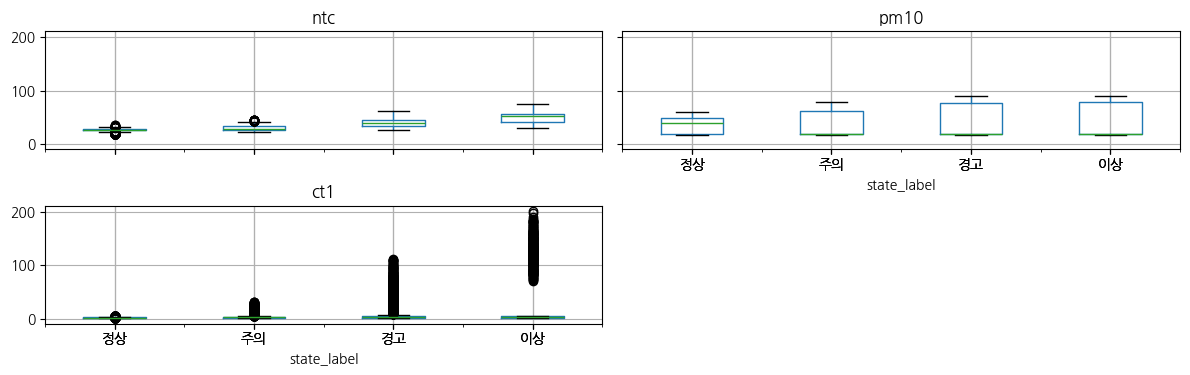

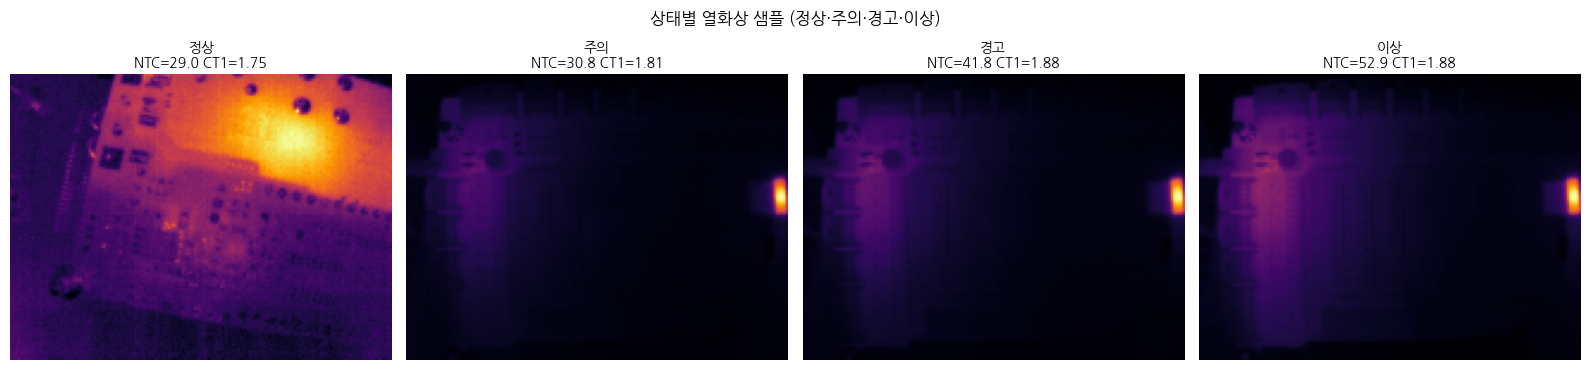

In [9]:
def thermal_bin_to_pil(bin_path: Path) -> Image.Image:
    """NumPy .bin 열화상 → inferno 컬러맵 RGB PIL Image."""
    arr = np.load(bin_path, allow_pickle=False)  # shape (120, 160), float ℃
    # 프레임마다 min-max 정규화 → 0~1 (절대온도보다 상대 패턴이 시각적으로 중요)
    norm = (arr - arr.min()) / (arr.max() - arr.min() + 1e-6)
    rgba = cm.inferno(norm)
    rgb = (rgba[:, :, :3] * 255).astype(np.uint8)
    return Image.fromarray(rgb)


# --- 전체 데이터 스캔 (PNG 변환 없음, 수 분 소요 가능) ---
eda_df = pd.DataFrame(scan_dataset_records())
print(f"전체 샘플: {len(eda_df):,}건")
print(f"  Training: {(eda_df['split']=='Training').sum():,}  Validation: {(eda_df['split']=='Validation').sum():,}")
print(f"  세션: {eda_df['session'].nunique()}개")

# state 0~3 순서 고정 (정상→주의→경고→이상)
state_order = [STATE_LABELS[s] for s in STATE_LABELS]
state_counts = eda_df["state_label"].value_counts().reindex(state_order, fill_value=0)
print("\n열화 상태 분포 (전체):")
display(state_counts.to_frame("건수"))

# --- 시각화: 상태 분포 + 센서 박스플롯 ---
setup_korean_matplotlib()
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
colors = {"정상": "#2ecc71", "주의": "#f1c40f", "경고": "#e67e22", "이상": "#e74c3c"}
bar_colors = [colors.get(l, "#95a5a6") for l in state_counts.index]
state_counts.plot(kind="bar", ax=axes[0], color=bar_colors, rot=0)
axes[0].set_title("열화 상태 분포")
axes[0].set_xlabel("상태")
axes[0].set_ylabel("건수")

sensor_cols = ["ntc", "pm10", "ct1"]
plot_df = eda_df[["state_label"] + sensor_cols].copy()
plot_df["state_label"] = pd.Categorical(plot_df["state_label"], categories=state_order, ordered=True)
plot_df.boxplot(column=sensor_cols, by="state_label", ax=axes[1])
axes[1].set_title("상태별 센서 분포")
plt.suptitle("")
plt.tight_layout()
plt.show()

# --- 상태별 열화상 1장씩 미리보기 (정상·주의·경고·이상) ---
preview = pick_samples_by_state(eda_df.to_dict("records"))
n = len(preview)
fig, axes = plt.subplots(1, n, figsize=(4 * n, 4))
if n == 1:
    axes = [axes]
for ax, rec in zip(axes, preview):
    ax.imshow(thermal_bin_to_pil(Path(rec["bin_path"])))
    ax.set_title(f"{rec['state_label']}\nNTC={rec['ntc']:.1f} CT1={rec['ct1']:.2f}", fontsize=10)
    ax.axis("off")
plt.suptitle("상태별 열화상 샘플 (정상·주의·경고·이상)")
plt.tight_layout()
plt.show()


## 3. BIN 열화상 → PNG + manifest 구축

열화상 `.bin`을 AI가 읽을 수 있는 PNG로 바꾸고, 센서·라벨과 **sample_id** 기준으로 한 줄(manifest)로 묶습니다.

| 파일 | 설명 |
|------|------|
| `.bin` | NumPy 열화상 배열 (120×160, ℃) — 열화상 카메라 raw |
| `.csv` | NTC·PM1.0·PM2.5·PM10·CT1~CT4 센서 1행 (아래 표 참고) |
| `.json` | `annotations.tagging.state` 열화 상태 (0~3) |

**CSV 센서 컬럼 (노트북·EDA에서 주로 사용)**

| 컬럼 | 단위 | 의미 |
|------|------|------|
| NTC | ℃ | 내부 온도 (예: 29.0℃) |
| PM10 | µg/m³ | 미세먼지 10µm 이하 (예: 50.0 µg/m³) |
| PM2.5 / PM1.0 | µg/m³ | 더 작은 입자 크기별 분진 |
| CT1 | A | 1번 전류 채널 (예: 1.75 A) |
| CT2~CT4 | A | 다른 회로/모터 전류 채널 |

### manifest란?

각 열화상 1장에 대한 **메타데이터 목록(JSON)** 입니다. 경로·센서·state·PNG 저장 위치가 들어가며, Qdrant 인덱싱과 검색 결과 역추적에 씁니다.

- `DEMO_MODE=True`이면 **상태별 균등 샘플링**(`sample_manifest_stratified`)으로 정상·주의·경고·이상이 모두 포함됩니다.
- 열화상 float 배열은 사람이 보기 어려우므로 **inferno 컬러맵**으로 RGB PNG를 만든 뒤 SigLIP2에 넣습니다.


BIN→PNG:   0%|          | 0/800 [00:00<?, ?it/s]

manifest: 800건, 신규 PNG 800개
상태 분포 (인덱싱 대상):


,count
state_label,
정상,200
주의,200
경고,200
이상,200


,sample_id,split,session,bin_path,csv_path,image_path,image_rel,state,state_label,ntc,pm10,pm25,ct1,ct2
0,agv01_0901_081240,Training,TS_agv_01_agv01_0901_0812,/content/data/conveyor_condition_monitoring/Tr...,/content/data/conveyor_condition_monitoring/Tr...,/content/data/conveyor_condition_monitoring/th...,Training/TS_agv_01_agv01_0901_0812/agv01_0901_...,0,정상,29.0,50.0,32.0,1.75,74.58
1,agv01_0901_081241,Training,TS_agv_01_agv01_0901_0812,/content/data/conveyor_condition_monitoring/Tr...,/content/data/conveyor_condition_monitoring/Tr...,/content/data/conveyor_condition_monitoring/th...,Training/TS_agv_01_agv01_0901_0812/agv01_0901_...,0,정상,29.0,50.0,31.0,1.66,74.56
2,agv01_0901_081242,Training,TS_agv_01_agv01_0901_0812,/content/data/conveyor_condition_monitoring/Tr...,/content/data/conveyor_condition_monitoring/Tr...,/content/data/conveyor_condition_monitoring/th...,Training/TS_agv_01_agv01_0901_0812/agv01_0901_...,0,정상,29.0,50.0,32.0,1.67,74.67
3,agv01_0901_081243,Training,TS_agv_01_agv01_0901_0812,/content/data/conveyor_condition_monitoring/Tr...,/content/data/conveyor_condition_monitoring/Tr...,/content/data/conveyor_condition_monitoring/th...,Training/TS_agv_01_agv01_0901_0812/agv01_0901_...,0,정상,29.0,51.0,32.0,1.88,74.52
4,agv01_0901_081244,Training,TS_agv_01_agv01_0901_0812,/content/data/conveyor_condition_monitoring/Tr...,/content/data/conveyor_condition_monitoring/Tr...,/content/data/conveyor_condition_monitoring/th...,Training/TS_agv_01_agv01_0901_0812/agv01_0901_...,0,정상,29.0,51.0,33.0,1.61,74.54


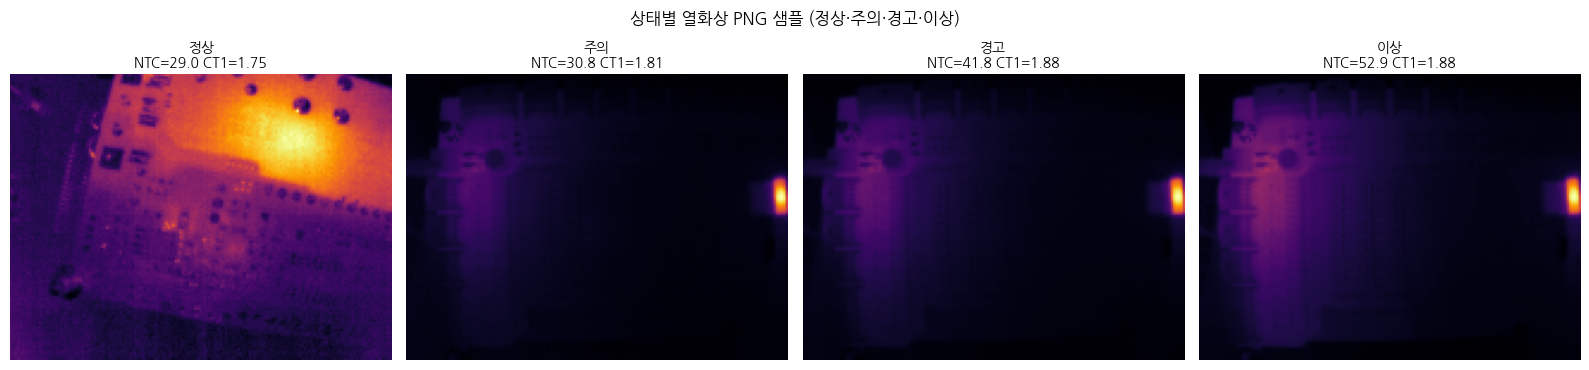

In [10]:
def thermal_bin_to_pil(bin_path: Path) -> Image.Image:
    """NumPy .bin 열화상 → inferno 컬러맵 RGB PIL Image."""
    arr = np.load(bin_path, allow_pickle=False)
    norm = (arr - arr.min()) / (arr.max() - arr.min() + 1e-6)
    rgba = cm.inferno(norm)
    rgb = (rgba[:, :, :3] * 255).astype(np.uint8)
    return Image.fromarray(rgb)


def build_manifest(max_samples: int | None = None, stratified: bool = True) -> list[dict]:
    """전체 스캔 후 (선택) 상태별 균등 샘플링."""
    records = scan_dataset_records()
    if max_samples is None:
        return records
    if stratified:
        return sample_manifest_stratified(records, max_samples)
    return records[:max_samples]


def convert_bins_to_png(records: list[dict]) -> int:
    """manifest 레코드의 BIN → PNG 변환 (없을 때만)."""
    converted = 0
    for rec in tqdm(records, desc="BIN→PNG"):
        out = Path(rec["image_path"])
        if out.exists():
            continue
        out.parent.mkdir(parents=True, exist_ok=True)
        thermal_bin_to_pil(Path(rec["bin_path"])).save(out)
        converted += 1
    return converted


# DEMO_MODE이면 MAX_SAMPLES만큼 상태별 균등 샘플, False면 전체 (~1만 장)
limit = MAX_SAMPLES if DEMO_MODE else None
manifest = build_manifest(max_samples=limit, stratified=DEMO_MODE)
if not manifest:
    raise RuntimeError("manifest가 비어 있습니다. 1단계 ZIP 추출을 먼저 실행하세요.")

new_png = convert_bins_to_png(manifest)
MANIFEST_PATH.write_text(json.dumps(manifest, ensure_ascii=False, indent=2), encoding="utf-8")

manifest_df = pd.DataFrame(manifest)
print(f"manifest: {len(manifest)}건, 신규 PNG {new_png}개")
print("상태 분포 (인덱싱 대상):")
state_order = [STATE_LABELS[s] for s in STATE_LABELS]
display(manifest_df["state_label"].value_counts().reindex(state_order, fill_value=0))
display(manifest_df.head())

# 상태별 대표 샘플 미리보기 (정상·주의·경고·이상 각 1장)
setup_korean_matplotlib()
preview_records = pick_samples_by_state(manifest)
n = len(preview_records)
fig, axes = plt.subplots(1, n, figsize=(4 * n, 4))
if n == 1:
    axes = [axes]
for ax, rec in zip(axes, preview_records):
    img_path = Path(rec["image_path"])
    if not img_path.exists():
        thermal_bin_to_pil(Path(rec["bin_path"])).save(img_path)
    ax.imshow(Image.open(img_path))
    ax.set_title(f"{rec['state_label']}\nNTC={rec['ntc']:.1f} CT1={rec['ct1']:.2f}", fontsize=10)
    ax.axis("off")
plt.suptitle("상태별 열화상 PNG 샘플 (정상·주의·경고·이상)")
plt.tight_layout()
plt.show()


## 4. SigLIP2 Embedding → Qdrant 인덱싱

### SigLIP2 (검색·Retriever)

Google의 **비전-언어 모델**입니다. 열화상 PNG와 한글 질문을 **1152차원 벡터**로 변환하고, 의미가 비슷하면 벡터 거리도 가깝게 만듭니다.

- `encode_images()`: PNG → 벡터
- `encode_texts()`: "과열 열화상" 같은 한글 → 벡터
- L2 정규화 후 **코사인 유사도** = 벡터 내적

### Qdrant (벡터 DB)

임베딩과 함께 **NTC·PM10·state_label** 같은 메타데이터(payload)를 저장합니다. 나중에 "이상(3)만 검색" 같은 **필터 검색**도 가능합니다.

> **Qdrant 로컬 모드**(`path=`)는 동일 폴더에 클라이언트 **1개만** 열 수 있습니다.
> `get_qdrant_client()` 싱글톤으로 재사용하고, 재인덱싱 전에는 `close_qdrant_client()`로 lock을 해제합니다.


In [11]:
class SigLIP2Encoder:
    """SigLIP2 So400M — 열화상·한글 텍스트 임베딩."""

    def __init__(self, model_id: str = SIGLIP2_MODEL_ID):
        # GPU면 float16으로 메모리 절약, CPU면 float32
        dtype = torch.float16 if device == "cuda" else torch.float32
        self.model = AutoModel.from_pretrained(model_id, torch_dtype=dtype).to(device).eval()
        self.processor = AutoProcessor.from_pretrained(model_id)  # 이미지 리사이즈·토큰화
        print(f"SigLIP2 로딩 완료: {model_id} ({device})")

    @staticmethod
    def _pool(output):
        # transformers 버전에 따라 Tensor 또는 pooler_output 반환
        return output if isinstance(output, torch.Tensor) else output.pooler_output

    @torch.no_grad()  # 추론 시 gradient 비활성 → 메모리·속도 절약
    def encode_images(self, images: list) -> np.ndarray:
        inputs = self.processor(images=images, return_tensors="pt").to(device)
        feats = self._pool(self.model.get_image_features(**inputs))
        feats = feats / feats.norm(dim=-1, keepdim=True)  # L2 정규화 → 코사인=내적
        return feats.cpu().numpy()

    @torch.no_grad()
    def encode_texts(self, texts: list[str]) -> np.ndarray:
        inputs = self.processor(
            text=texts, padding="max_length", truncation=True,
            max_length=64, return_tensors="pt",
        ).to(device)
        feats = self._pool(self.model.get_text_features(**inputs))
        feats = feats / feats.norm(dim=-1, keepdim=True)
        return feats.cpu().numpy()


siglip_encoder = SigLIP2Encoder()


config.json:   0%|          | 0.00/559 [00:00<?, ?B/s]

[transformers] Model config: bos_token_id must be `None` or an integer within the vocabulary (between 0 and 31999), got 49406. This may result in unexpected behavior.
[transformers] Model config: eos_token_id must be `None` or an integer within the vocabulary (between 0 and 31999), got 49407. This may result in unexpected behavior.
[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors:   0%|          | 0.00/4.54G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/888 [00:00<?, ?it/s]

preprocessor_config.json:   0%|          | 0.00/394 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/47.2k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/34.4M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/636 [00:00<?, ?B/s]

SigLIP2 로딩 완료: google/siglip2-so400m-patch14-384 (cuda)


In [12]:
def close_qdrant_client():
    """Qdrant 로컬 lock 해제. 재인덱싱·재연결 전에 호출."""
    global qdrant_client
    if qdrant_client is not None:
        qdrant_client.close()
        qdrant_client = None


def get_qdrant_client() -> QdrantClient:
    """Qdrant 로컬 클라이언트 싱글톤 (동일 path 중복 open 방지)."""
    global qdrant_client
    if qdrant_client is None:
        qdrant_client = QdrantClient(path=str(QDRANT_DIR))
    return qdrant_client


def ensure_siglip_collection(client: QdrantClient, recreate: bool = False):
    exists = client.collection_exists(COLLECTION_NAME)
    if recreate and exists:
        client.delete_collection(COLLECTION_NAME)
        exists = False
    if not exists:
        client.create_collection(
            collection_name=COLLECTION_NAME,
            vectors_config=models.VectorParams(size=EMBED_DIM, distance=models.Distance.COSINE),
        )
        print(f"Qdrant 컬렉션 생성: {COLLECTION_NAME}")
    else:
        print(f"Qdrant 컬렉션 사용: {COLLECTION_NAME}")


def record_to_payload(rec: dict) -> dict:
    """Qdrant payload — 검색 결과에서 센서·상태·경로 역추적용."""
    return {
        "sample_id": rec["sample_id"],
        "split": rec["split"],
        "session": rec["session"],
        "image_path": rec["image_path"],
        "state": rec["state"],
        "state_label": rec["state_label"],
        "ntc": rec["ntc"],
        "pm10": rec["pm10"],
        "pm25": rec["pm25"],
        "ct1": rec["ct1"],
        "ct2": rec["ct2"],
    }


def index_manifest_to_qdrant(
    records: list[dict],
    encoder: SigLIP2Encoder,
    batch_size: int = SIGLIP2_BATCH_SIZE,
    recreate: bool = False,
) -> int:
    if recreate:
        close_qdrant_client()  # REBUILD_INDEX=True 시 기존 lock·컬렉션 정리
    client = get_qdrant_client()
    ensure_siglip_collection(client, recreate=recreate)

    total = 0
    for i in tqdm(range(0, len(records), batch_size), desc="Qdrant 인덱싱"):
        batch = records[i : i + batch_size]
        images = [Image.open(r["image_path"]).convert("RGB") for r in batch]
        embeddings = encoder.encode_images(images)
        points = []
        for rec, emb in zip(batch, embeddings):
            # Qdrant point id는 UUID 형식 필요 (sample_id 기반 deterministic UUID5)
            point_id = str(uuid.uuid5(uuid.NAMESPACE_DNS, rec["sample_id"]))
            points.append(models.PointStruct(
                id=point_id,
                vector=emb.tolist(),
                payload=record_to_payload(rec),
            ))
        client.upsert(collection_name=COLLECTION_NAME, points=points)
        total += len(points)
    print(f"Qdrant 인덱싱 완료: {total}건")
    return total


index_manifest_to_qdrant(manifest, siglip_encoder, recreate=REBUILD_INDEX)
# CPU : 약 58분 소요
# RTX 3060 : 약 1~3분 소요


Qdrant 컬렉션 생성: conveyor_condition_siglip2


Qdrant 인덱싱:   0%|          | 0/100 [00:00<?, ?it/s]

Qdrant 인덱싱 완료: 800건


800

## 5. 한글 텍스트 검색 (SigLIP2 + Qdrant)

한글 질문 → SigLIP2 텍스트 벡터 → Qdrant에서 **코사인 Top-k** 열화상 검색.

```
"이송장치 과열·열화 징후"  →  SigLIP2 text embedding
                          →  Qdrant query_points (코사인)
                          →  Top-k 열화상 + 센서 payload
```

**score(점수)**: 높을수록 질문과 해당 열화상이 **의미적으로 더 관련** 있음. 순위 비교가 중요합니다.

**예시 질의**
- "이송장치 과열 열화상"
- "전류 이상 징후가 있는 열화상"
- "정상 상태 열화상"

`state_filter="3"`을 넣으면 **이상** 라벨만 대상으로 필터 검색할 수 있습니다.


Query: 이송장치 과열·열화 징후가 보이는 열화상


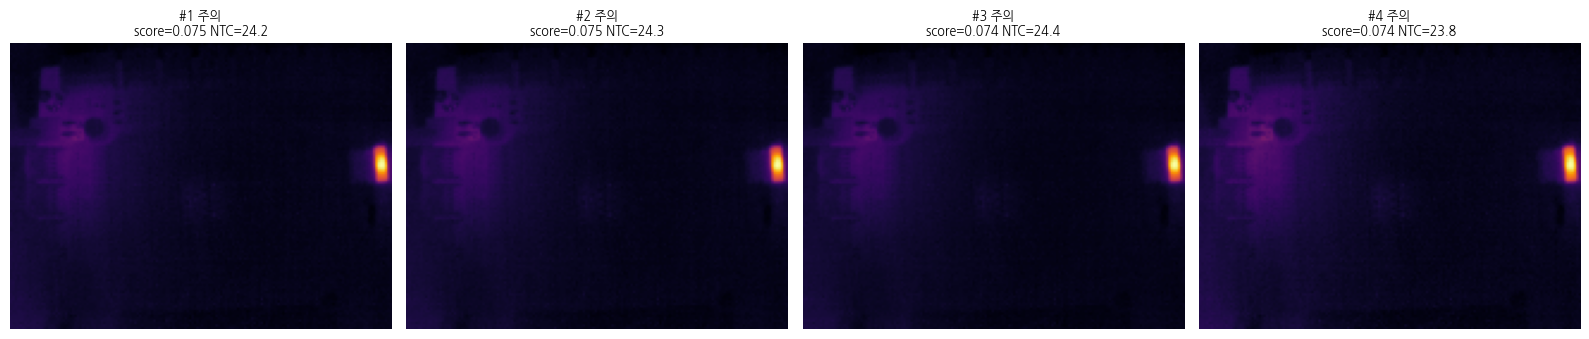

,rank,score,state,NTC,PM10,CT1,sample_id
0,1,0.0753,주의,24.20,55.0,2.79,agv05_0903_041134
1,2,0.0748,주의,24.31,56.0,2.82,agv05_0903_041135
2,3,0.0741,주의,24.40,55.0,3.08,agv05_0903_041136
3,4,0.0738,주의,23.76,54.0,2.66,agv05_0903_041132


In [13]:
def search_thermal_images(
    query: str,
    encoder: SigLIP2Encoder,
    client: QdrantClient,
    top_k: int = TOP_K,
    state_filter: str | None = None,
) -> list[dict]:
    """한글 질문 → SigLIP2 → Qdrant 코사인 Top-k."""
    query_vec = encoder.encode_texts([query])[0].tolist()
    qfilter = None
    if state_filter is not None:
        # payload.state 필드로 라벨 필터 (예: "3"=이상만)
        qfilter = models.Filter(must=[
            models.FieldCondition(key="state", match=models.MatchValue(value=state_filter))
        ])
    response = client.query_points(
        collection_name=COLLECTION_NAME,
        query=query_vec,
        query_filter=qfilter,
        limit=top_k,
        with_payload=True,
    )
    hits = []
    for rank, point in enumerate(response.points, 1):
        hits.append({"rank": rank, "score": float(point.score), "payload": point.payload})
    return hits


def show_search_hits(hits: list[dict]):
    """검색된 열화상 + 센서 메타 테이블 시각화."""
    setup_korean_matplotlib()
    n = len(hits)
    if n == 0:
        print("검색 결과 없음")
        return
    fig, axes = plt.subplots(1, n, figsize=(4 * n, 4))
    if n == 1:
        axes = [axes]
    rows = []
    for ax, hit in zip(axes, hits):
        p = hit["payload"]
        ax.imshow(Image.open(p["image_path"]))
        ax.set_title(
            f"#{hit['rank']} {p['state_label']}\n"
            f"score={hit['score']:.3f} NTC={p['ntc']:.1f}",
            fontsize=9,
        )
        ax.axis("off")
        rows.append({
            "rank": hit["rank"],
            "score": round(hit["score"], 4),
            "state": p["state_label"],
            "NTC": p["ntc"],
            "PM10": p["pm10"],
            "CT1": p["ct1"],
            "sample_id": p["sample_id"],
        })
    plt.tight_layout()
    plt.show()
    display(pd.DataFrame(rows))


QUERY = "이송장치 과열·열화 징후가 보이는 열화상"
hits = search_thermal_images(QUERY, siglip_encoder, get_qdrant_client(), top_k=TOP_K)
print(f"Query: {QUERY}")
show_search_hits(hits)


## 6. Qwen3-VL 멀티모달 분석

검색된 열화상 **이미지**와 **센서 수치(NTC, PM10, CT1…)** 를 Qwen3-VL(Vision Language Model)에 함께 넣어, 사람이 읽을 수 있는 **한글 분석문**을 생성합니다.

| 역할 | SigLIP2 + Qdrant | Qwen3-VL |
|------|------------------|----------|
| 목적 | 빠른 **검색** (Top-k) | 정밀 **분석·설명** |
| 입력 | 텍스트 쿼리 | 이미지 + 센서 + 질문 |
| 출력 | 유사 열화상 목록 | "과열 징후, NTC 상승…" 등 서술 |

> SigLIP2와 Qwen3-VL을 **동시에 GPU**에 올리면 VRAM 부족(OOM)이 날 수 있습니다.
> 분석 전 `release_siglip()`으로 SigLIP2를 메모리에서 내린 뒤 Qwen3-VL을 로드합니다.


In [14]:
def release_siglip():
    """Qwen3-VL 로드 전 SigLIP2 GPU 메모리 해제."""
    global siglip_encoder
    if siglip_encoder is not None:
        del siglip_encoder
        siglip_encoder = None
        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
        print("SigLIP2 GPU 메모리 해제 완료")


def load_qwen():
    global qwen_model, qwen_processor
    if qwen_model is not None:
        return qwen_model, qwen_processor
    dtype = torch.float16 if device == "cuda" else torch.float32
    qwen_model = Qwen3VLForConditionalGeneration.from_pretrained(
        QWEN_MODEL_ID, torch_dtype=dtype, device_map="auto" if device == "cuda" else None,
    )
    qwen_processor = AutoProcessor.from_pretrained(QWEN_MODEL_ID)
    if device != "cuda":
        qwen_model = qwen_model.to(device)
    qwen_model.eval()
    print(f"Qwen3-VL 로딩 완료: {QWEN_MODEL_ID}")
    return qwen_model, qwen_processor


def analyze_with_qwen(query: str, hits: list[dict], max_images: int = 3) -> str:
    release_siglip()
    model, processor = load_qwen()
    images = [Image.open(h["payload"]["image_path"]).convert("RGB") for h in hits[:max_images]]
    sensor_lines = []
    for h in hits[:max_images]:
        p = h["payload"]
        sensor_lines.append(
            f"- {p['sample_id']}: 상태={p['state_label']}, NTC={p['ntc']:.2f}, "
            f"PM10={p['pm10']:.1f}, CT1={p['ct1']:.2f}, CT2={p['ct2']:.2f}"
        )
    sensor_text = "\n".join(sensor_lines)
    prompt = (
        f"질문: {query}\n\n"
        f"검색된 열화상의 센서 수치:\n{sensor_text}\n\n"
        "위 열화상 이미지와 센서 데이터를 종합하여 이송장치의 열화·이상 여부를 "
        "한국어로 간결히 분석하세요. 근거(온도·전류·상태)를 포함하세요."
    )
    messages = [{"role": "user", "content": [
        *[{ "type": "image", "image": img } for img in images],
        {"type": "text", "text": prompt},
    ]}]
    inputs = processor.apply_chat_template(
        messages, tokenize=True, add_generation_prompt=True,
        return_dict=True, return_tensors="pt",
    ).to(model.device)
    with torch.no_grad():
        out_ids = model.generate(**inputs, max_new_tokens=512, do_sample=False)
    trimmed = [o[len(i):] for i, o in zip(inputs.input_ids, out_ids)]
    answer = processor.batch_decode(trimmed, skip_special_tokens=True)[0]
    return answer.strip()


answer = analyze_with_qwen(QUERY, hits)
display(Markdown(answer))


SigLIP2 GPU 메모리 해제 완료


config.json:   0%|          | 0.00/1.50k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/4.26G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/625 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/269 [00:00<?, ?B/s]

...

merges.txt:   0%|          | 0.00/1.67M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/7.03M [00:00<?, ?B/s]

video_preprocessor_config.json:   0%|          | 0.00/385 [00:00<?, ?B/s]

Qwen3-VL 로딩 완료: Qwen/Qwen3-VL-2B-Instruct


이송장치는 현재 **주의** 상태이며, **열화·이상의 징후**가 보입니다.

- **온도**: 센서 데이터를 분석한 결과, NTC(냉각기온센서) 값은 24.20~24.40도로, **정상 범위 내에** 있습니다. 이는 장치의 온도가 과열되지 않았음을 의미합니다.
- **전류**: CT1(전류)와 CT2(전류) 값은 2.79~3.08A로, **정상 범위 내에** 있으며, 전류가 과도하게 증가하지 않았습니다.
- **PM10**: PM10 값은 55.0~56.0, 이는 **정상 범위 내에** 있으며, 먼지나 공기 중의 오염물질이 많지 않음을 의미합니다.

결론적으로, 이송장치는 **온도와 전류가 정상**이며, **PM10도 정상**입니다. 따라서 **열화·이상의 징후가 보이지 않으며, 현재 상태는 안전한 것으로 판단됩니다.**

## 7. 통합 파이프라인

`run_conveyor_rag()` 한 함수로 **검색 → 시각화 → (선택) Qwen3-VL 분석**을 실행합니다.

| 인자 | 설명 |
|------|------|
| `query` | 한글 검색 질문 |
| `top_k` | 검색 결과 개수 |
| `use_qwen` | `False`이면 검색·차트만 (빠른 테스트) |
| `state_filter` | `"0"`~`"3"` — 특정 state만 검색 |

Qwen 분석 후 SigLIP2가 해제되므로, 다시 검색하려면 함수 내부에서 **자동 재로딩**됩니다.


### 실행 예시

아래 셀의 `run_conveyor_rag()`를 호출하면 **한 줄의 한글 질문**으로 전체 파이프라인을 돌릴 수 있습니다.

- 처음에는 `use_qwen=False`로 **검색·차트만** 확인하는 것을 권장합니다 (Qwen3-VL 로딩·VRAM 부담이 큼).
- 검색 결과가 만족스러우면 `use_qwen=True`로 **VLM 분석문**까지 받아보세요.


SigLIP2 재로딩 (검색용)...


Loading weights:   0%|          | 0/888 [00:00<?, ?it/s]

SigLIP2 로딩 완료: google/siglip2-so400m-patch14-384 (cuda)


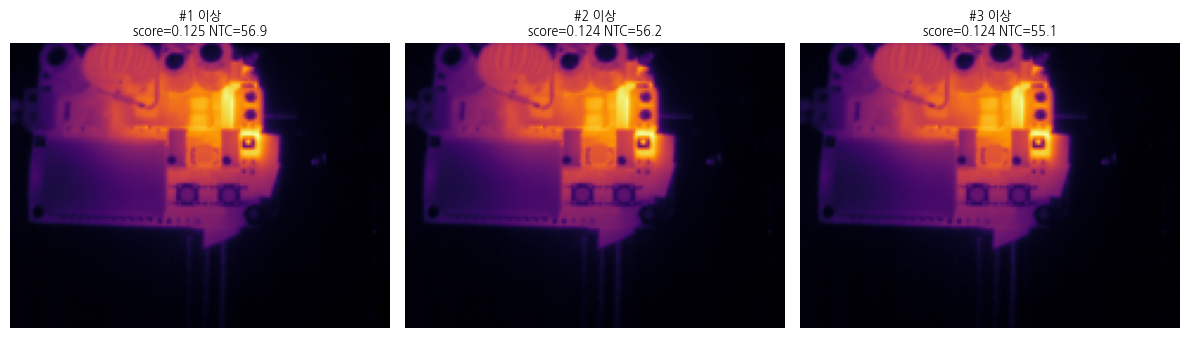

,rank,score,state,NTC,PM10,CT1,sample_id
0,1,0.1245,이상,56.93,83.0,1.76,agv09_1026_214648
1,2,0.1240,이상,56.22,83.0,2.01,agv09_1026_214644
2,3,0.1237,이상,55.07,83.0,1.88,agv09_1026_214638


{'query': '전류 CT 센서 이상이 의심되는 열화상',
 'hits': [{'rank': 1,
   'score': 0.12452825436180048,
   'payload': {'sample_id': 'agv09_1026_214648',
    'split': 'Training',
    'session': 'TS_agv_09_agv09_1026_2140',
    'image_path': '/content/data/conveyor_condition_monitoring/thermal_images/Training/TS_agv_09_agv09_1026_2140/agv09_1026_214648.png',
    'state': '3',
    'state_label': '이상',
    'ntc': 56.93,
    'pm10': 83.0,
    'pm25': 49.0,
    'ct1': 1.76,
    'ct2': 222.6}},
  {'rank': 2,
   'score': 0.12403531638494802,
   'payload': {'sample_id': 'agv09_1026_214644',
    'split': 'Training',
    'session': 'TS_agv_09_agv09_1026_2140',
    'image_path': '/content/data/conveyor_condition_monitoring/thermal_images/Training/TS_agv_09_agv09_1026_2140/agv09_1026_214644.png',
    'state': '3',
    'state_label': '이상',
    'ntc': 56.22,
    'pm10': 83.0,
    'pm25': 49.0,
    'ct1': 2.01,
    'ct2': 210.22}},
  {'rank': 3,
   'score': 0.1236753623462477,
   'payload': {'sample_id': 'agv09_102

In [15]:
def run_conveyor_rag(
    query: str,
    top_k: int = TOP_K,
    use_qwen: bool = True,
    state_filter: str | None = None,
) -> dict:
    """한글 Query → SigLIP2 → Qdrant Top-k → (선택) Qwen3-VL + 센서 분석"""
    global siglip_encoder
    if siglip_encoder is None:
        # Qwen 분석 후 SigLIP2가 해제된 경우 — 검색을 위해 다시 로드
        print("SigLIP2 재로딩 (검색용)...")
        siglip_encoder = SigLIP2Encoder()
    hits = search_thermal_images(
        query, siglip_encoder, get_qdrant_client(),
        top_k=top_k, state_filter=state_filter,
    )
    show_search_hits(hits)
    result = {"query": query, "hits": hits, "answer": None}
    if use_qwen and hits:
        result["answer"] = analyze_with_qwen(query, hits)
        display(Markdown(result["answer"]))
    return result


# 예시: use_qwen=False이면 검색·차트만 빠르게 확인
run_conveyor_rag("전류 CT 센서 이상이 의심되는 열화상", top_k=3, use_qwen=False)


### state 필터 검색 예시

Qdrant payload의 `state` 필드로 **특정 열화 라벨만** 검색 대상으로 제한합니다.
재인덱싱 없이 `run_conveyor_rag(..., state_filter="3")`처럼 호출만 바꾸면 됩니다.

| `state_filter` | 라벨 | 용도 예 |
|----------------|------|---------|
| `"0"` | 정상 | 정상 패턴 기준선 비교 |
| `"1"` | 주의 | 초기 이상 징후 탐색 |
| `"2"` | 경고 | 악화 추세 샘플 검색 |
| `"3"` | 이상 | 명확한 이상·과열 사례만 Top-k |

> `state_filter=None`(기본값)이면 manifest 전체가 검색 대상입니다.


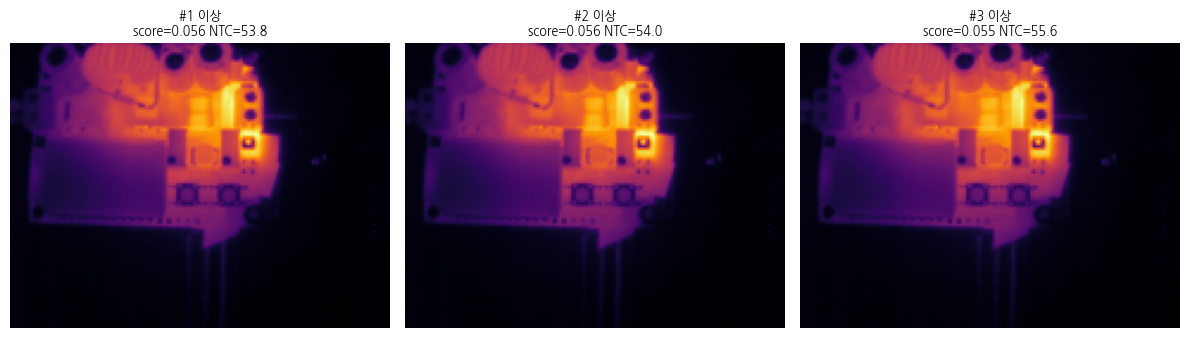

,rank,score,state,NTC,PM10,CT1,sample_id
0,1,0.0561,이상,53.80,83.0,1.81,agv09_1026_214632
1,2,0.0561,이상,54.00,83.0,2.10,agv09_1026_214633
2,3,0.0551,이상,55.65,83.0,1.88,agv09_1026_214641


{'query': '이송장치 과열·열화 이상 징후가 보이는 열화상',
 'hits': [{'rank': 1,
   'score': 0.056118219428625826,
   'payload': {'sample_id': 'agv09_1026_214632',
    'split': 'Training',
    'session': 'TS_agv_09_agv09_1026_2140',
    'image_path': '/content/data/conveyor_condition_monitoring/thermal_images/Training/TS_agv_09_agv09_1026_2140/agv09_1026_214632.png',
    'state': '3',
    'state_label': '이상',
    'ntc': 53.8,
    'pm10': 83.0,
    'pm25': 47.0,
    'ct1': 1.81,
    'ct2': 171.22}},
  {'rank': 2,
   'score': 0.056075712863649894,
   'payload': {'sample_id': 'agv09_1026_214633',
    'split': 'Training',
    'session': 'TS_agv_09_agv09_1026_2140',
    'image_path': '/content/data/conveyor_condition_monitoring/thermal_images/Training/TS_agv_09_agv09_1026_2140/agv09_1026_214633.png',
    'state': '3',
    'state_label': '이상',
    'ntc': 54.0,
    'pm10': 83.0,
    'pm25': 48.0,
    'ct1': 2.1,
    'ct2': 173.74}},
  {'rank': 3,
   'score': 0.05513511160029068,
   'payload': {'sample_id': 'agv0

In [17]:
# 이상(3) 샘플만 검색 — 과열·열화 이상 징후
run_conveyor_rag(
    "이송장치 과열·열화 이상 징후가 보이는 열화상",
    top_k=3,
    state_filter="3",
    use_qwen=False,
)

# 정상(0)만 검색 — 비교·기준선 확인용
# run_conveyor_rag("정상 상태 열화상 패턴", top_k=3, state_filter="0", use_qwen=False)

# 이상만 검색 + Qwen3-VL 분석 (VRAM 여유 있을 때)
# run_conveyor_rag("이상 상태 열화상의 원인 분석", top_k=3, state_filter="3", use_qwen=True)


## 요약·트러블슈팅

노트북을 **위에서 아래로 순서대로** 실행하면 Visual RAG 파이프라인이 완성됩니다.
중간 셀을 건너뛰면 `manifest`·Qdrant·SigLIP2가 없어 이후 단계에서 오류가 납니다.

### 실행 순서

| 순서 | 섹션 | 핵심 작업 |
|------|------|-----------|
| 0 | 환경 설정 | 경로·모델·`DEMO_MODE` 변수 정의 |
| 1 | ZIP 압축 해제 | `data/conveyor_condition_monitoring/` 생성 |
| 2 | EDA | 상태·센서 분포·열화상 샘플 확인 |
| 3 | manifest | BIN→PNG 변환 + 메타 JSON 저장 |
| 4 | SigLIP2 + Qdrant | 임베딩·벡터 DB 인덱싱 |
| 5 | 검색 | 한글 Query → Top-k 열화상 |
| 6 | Qwen3-VL | 검색 결과 기반 멀티모달 분석 |
| 7 | 통합 파이프라인 | `run_conveyor_rag()` — 기본·state 필터 검색 |

### 파이프라인 요약

| 단계 | 기술 | 결과 |
|------|------|------|
| 압축 해제 | ZIP → `data/conveyor_condition_monitoring/` | Training/Validation 데이터 |
| EDA | 상태·센서 분포 차트 | 정상·주의·경고·이상 전체 확인 |
| 전처리 | BIN → PNG + manifest | 열화상 + 센서 + 라벨 매칭 |
| 임베딩 | SigLIP2 | 1152차원 벡터 |
| 검색 | Qdrant 코사인 | Top-k 열화상 |
| 생성 | Qwen3-VL | 센서·열화상 종합 분석 |

### 자주 겪는 문제

| 증상 | 해결 |
|------|------|
| `FileNotFoundError` (ZIP) | 프로젝트 루트에 `Conveyor_Condition_Monitoring.zip` 배치 |
| `AlreadyLocked` (Qdrant) | Kernel Restart 후 순서대로 실행 |
| GPU OOM | `DEMO_MODE=True`, `MAX_SAMPLES` 축소, `SIGLIP2_BATCH_SIZE=4` |
| 검색 품질 낮음 | `DEMO_MODE=False`로 더 많은 샘플 인덱싱 |
| 한글 폴더명 깨짐 | ZIP 추출 셀 재실행 (CP949 복원 로직이 자동 재추출) |
| EDA·manifest 느림 | 전체 BIN 1만+건 스캔 — DEMO_MODE로 인덱싱만 줄이면 됨 |
| state 필터 결과 없음 | `DEMO_MODE`에서 해당 state 샘플이 manifest에 포함됐는지 확인 |
